In [ ]:
# --- repo bootstrap -------------------------------------------------------
# Resolves the repository root and chdirs to it, so every path below is
# repo-relative and this notebook runs from any checkout location.
import os
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / ".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
print("repo root:", ROOT)


In [1]:
%pip install -q "ultralytics>=8.3" "supervision>=0.24" opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import cv2
import numpy as np
import supervision as sv
from supervision.metrics import MeanAveragePrecision, MetricTarget
from ultralytics import YOLO

# --- weights (from your pipeline.ipynb) ---
PERSON_WEIGHTS = "models/person/yolo11l_ep200/best.pt"
PPE_WEIGHTS    = "models/ppe/yolo11l_ep200/best.pt"

# --- test set (Roboflow YOLOv11 export, stretched 640x640, all 5 classes) ---
TEST_IMAGES_DIR = Path("data/benchmarks/cascade_testset_v1/test/images")
TEST_LABELS_DIR = Path("data/benchmarks/cascade_testset_v1/test/labels")
TEST_DATA_YAML  = Path("data/benchmarks/cascade_testset_v1/data.yaml")

# --- class taxonomy (matched by NAME, not index) ---
PERSON_CLASSES = ["half_person", "person"]   # crop sources
PPE_CLASSES    = ["boot", "helmet", "jacket"]  # scored end-to-end

# --- input sizes (must match training/inference) ---
IMG_SIZE  = 640            # person stage, full image
PPE_W, PPE_H = 171, 455    # crop resize (width, height)

# --- thresholds ---
PERSON_GATE_CONF = 0.50    # deployment operating point for the person gate
CONF_FOR_MAP     = 0.001   # low conf so mAP sees the full PR curve
OPERATING_CONF   = 0.50    # used only for the confusion-matrix / P-R table
PERSON_NMS_IOU   = 0.70    # matches your pipeline's NMS
PPE_NMS_IOU      = 0.50    # cross-crop duplicate removal
PR_IOU           = 0.50

person_model = YOLO(PERSON_WEIGHTS)
ppe_model    = YOLO(PPE_WEIGHTS)
print("person model classes:", person_model.names)
print("ppe model classes   :", ppe_model.names)

person model classes: {0: 'half_person', 1: 'person'}
ppe model classes   : {0: 'boot', 1: 'helmet', 2: 'jacket'}


In [3]:
def remap_by_name(det: sv.Detections, src_names, dst_classes) -> sv.Detections:
    """Keep only detections whose class name is in dst_classes and renumber
    their class_id to that canonical list's index order."""
    if isinstance(src_names, dict):
        src_names = [src_names[i] for i in range(len(src_names))]
    dst_index = {name: i for i, name in enumerate(dst_classes)}
    if len(det) == 0:
        return det
    mask = np.array([src_names[c] in dst_index for c in det.class_id], dtype=bool)
    det = det[mask]
    if len(det):
        det.class_id = np.array([dst_index[src_names[c]] for c in det.class_id])
    return det


gt_dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=str(TEST_IMAGES_DIR),
    annotations_directory_path=str(TEST_LABELS_DIR),
    data_yaml_path=str(TEST_DATA_YAML),
)
print("GT class order:", gt_dataset.classes)
print("images:", len(gt_dataset))

GT class order: ['boot', 'half_person', 'helmet', 'jacket', 'person']
images: 49


In [4]:
person_preds, person_targets = [], []
for image_path, image, target in gt_dataset:
    if image is None:
        image = cv2.imread(image_path)
    r = person_model.predict(image, imgsz=IMG_SIZE, classes=[0, 1],
                             conf=CONF_FOR_MAP, verbose=False)[0]
    pred = remap_by_name(sv.Detections.from_ultralytics(r), person_model.names, PERSON_CLASSES)
    tgt  = remap_by_name(target, gt_dataset.classes, PERSON_CLASSES)
    person_preds.append(pred)
    person_targets.append(tgt)

pm = MeanAveragePrecision(metric_target=MetricTarget.BOXES)
pm.update(person_preds, person_targets)
pr = pm.compute()
print("=== Person detector (component) ===")
print(f"mAP@0.5      : {pr.map50:.4f}")
print(f"mAP@0.5:0.95 : {pr.map50_95:.4f}")

=== Person detector (component) ===
mAP@0.5      : 0.7526
mAP@0.5:0.95 : 0.5089


In [5]:
def run_cascade(image: np.ndarray) -> sv.Detections:
    """Full two-stage pipeline on one 640x640 image -> PPE detections (640x640 frame)."""
    pr = person_model.predict(image, imgsz=IMG_SIZE, classes=[0, 1],
                              conf=PERSON_GATE_CONF, verbose=False)[0]
    persons = sv.Detections.from_ultralytics(pr)
    if len(persons):
        persons = persons.with_nms(threshold=PERSON_NMS_IOU, class_agnostic=True)

    collected = []
    for x1, y1, x2, y2 in persons.xyxy.astype(int):
        x1, y1 = max(0, x1), max(0, y1)
        if x2 <= x1 or y2 <= y1:
            continue
        crop = image[y1:y2, x1:x2]
        ch, cw = crop.shape[:2]
        crop_resized = cv2.resize(crop, (PPE_W, PPE_H))  # stretch, matching training

        pr2 = ppe_model.predict(crop_resized, imgsz=[PPE_H, PPE_W], classes=[0, 1, 2],
                                conf=CONF_FOR_MAP, verbose=False)[0]
        ppe = remap_by_name(sv.Detections.from_ultralytics(pr2), ppe_model.names, PPE_CLASSES)
        if len(ppe) == 0:
            continue
        # 171x455 crop frame -> original crop pixels -> 640x640 image frame
        ppe.xyxy[:, [0, 2]] = ppe.xyxy[:, [0, 2]] * (cw / PPE_W) + x1
        ppe.xyxy[:, [1, 3]] = ppe.xyxy[:, [1, 3]] * (ch / PPE_H) + y1
        collected.append(ppe)

    if not collected:
        return sv.Detections.empty()
    merged = sv.Detections.merge(collected)
    return merged.with_nms(threshold=PPE_NMS_IOU, class_agnostic=False)

In [6]:
ppe_preds, ppe_targets, paths = [], [], []
for image_path, image, target in gt_dataset:
    if image is None:
        image = cv2.imread(image_path)
    ppe_preds.append(run_cascade(image))
    ppe_targets.append(remap_by_name(target, gt_dataset.classes, PPE_CLASSES))
    paths.append(image_path)

# --- mAP across the full PR curve ---
m = MeanAveragePrecision(metric_target=MetricTarget.BOXES)
m.update(ppe_preds, ppe_targets)
res = m.compute()
print("=== End-to-end PPE pipeline ===")
print(f"mAP@0.5      : {res.map50:.4f}")
print(f"mAP@0.75     : {res.map75:.4f}")
print(f"mAP@0.5:0.95 : {res.map50_95:.4f}")

# --- operating point (conf >= 0.50): confusion matrix + per-class P/R ---
preds_at_op = [d[d.confidence >= OPERATING_CONF] if len(d) else d for d in ppe_preds]
cm = sv.ConfusionMatrix.from_detections(
    predictions=preds_at_op, targets=ppe_targets,
    classes=PPE_CLASSES, iou_threshold=PR_IOU,
)
mat = np.array(cm.matrix)
print(f"\nConfusion matrix @conf={OPERATING_CONF}, IoU={PR_IOU} "
      f"(rows=pred, cols=true; last index=background):")
print(mat.astype(int))
print("class order:", PPE_CLASSES, "+ background")

for i, name in enumerate(PPE_CLASSES):
    tp = mat[i, i]
    fp = mat[i, :].sum() - tp     # predicted i, was something else / background
    fn = mat[:, i].sum() - tp     # was i, predicted something else / missed
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    print(f"{name:8s}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")


WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max stride 32, updating to [480, 192]
WARNING ⚠️ imgsz=[455, 171] must be multiple of max st

In [7]:
import os
import csv

OUT_DIR = Path("outputs/reports/cascade_eval_v1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def draw(image, det, color):
    out = image.copy()
    for (x1, y1, x2, y2), cid in zip(det.xyxy.astype(int), det.class_id):
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        cv2.putText(out, PPE_CLASSES[cid], (x1, max(12, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return out

def save_comparison(image_path, preds, gt, out_dir):
    img = cv2.imread(str(image_path))
    if img is None:
        return
    pred_vis = draw(img, preds, (0, 255, 0))
    gt_vis   = draw(img, gt, (0, 0, 255))
    combined = np.concatenate([pred_vis, gt_vis], axis=1)
    out_path = out_dir / f"{Path(image_path).stem}_comparison.png"
    cv2.imwrite(str(out_path), combined)

summary_path = OUT_DIR / "summary.txt"
with open(summary_path, "w") as f:
    f.write("=== End-to-end PPE pipeline ===\n")
    f.write(f"mAP@0.5      : {res.map50:.4f}\n")
    f.write(f"mAP@0.75     : {res.map75:.4f}\n")
    f.write(f"mAP@0.5:0.95 : {res.map50_95:.4f}\n\n")

    f.write(f"Confusion matrix @conf={OPERATING_CONF}, IoU={PR_IOU}\n")
    f.write(np.array2string(mat.astype(int), separator=", "))
    f.write("\n\n")
    f.write("class order: " + ", ".join(PPE_CLASSES) + " + background\n\n")

    for i, name in enumerate(PPE_CLASSES):
        tp = mat[i, i]
        fp = mat[i, :].sum() - tp
        fn = mat[:, i].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        f.write(f"{name:8s}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}\n")

for image_path, preds, gt in zip(paths, preds_at_op, ppe_targets):
    save_comparison(image_path, preds, gt, OUT_DIR)

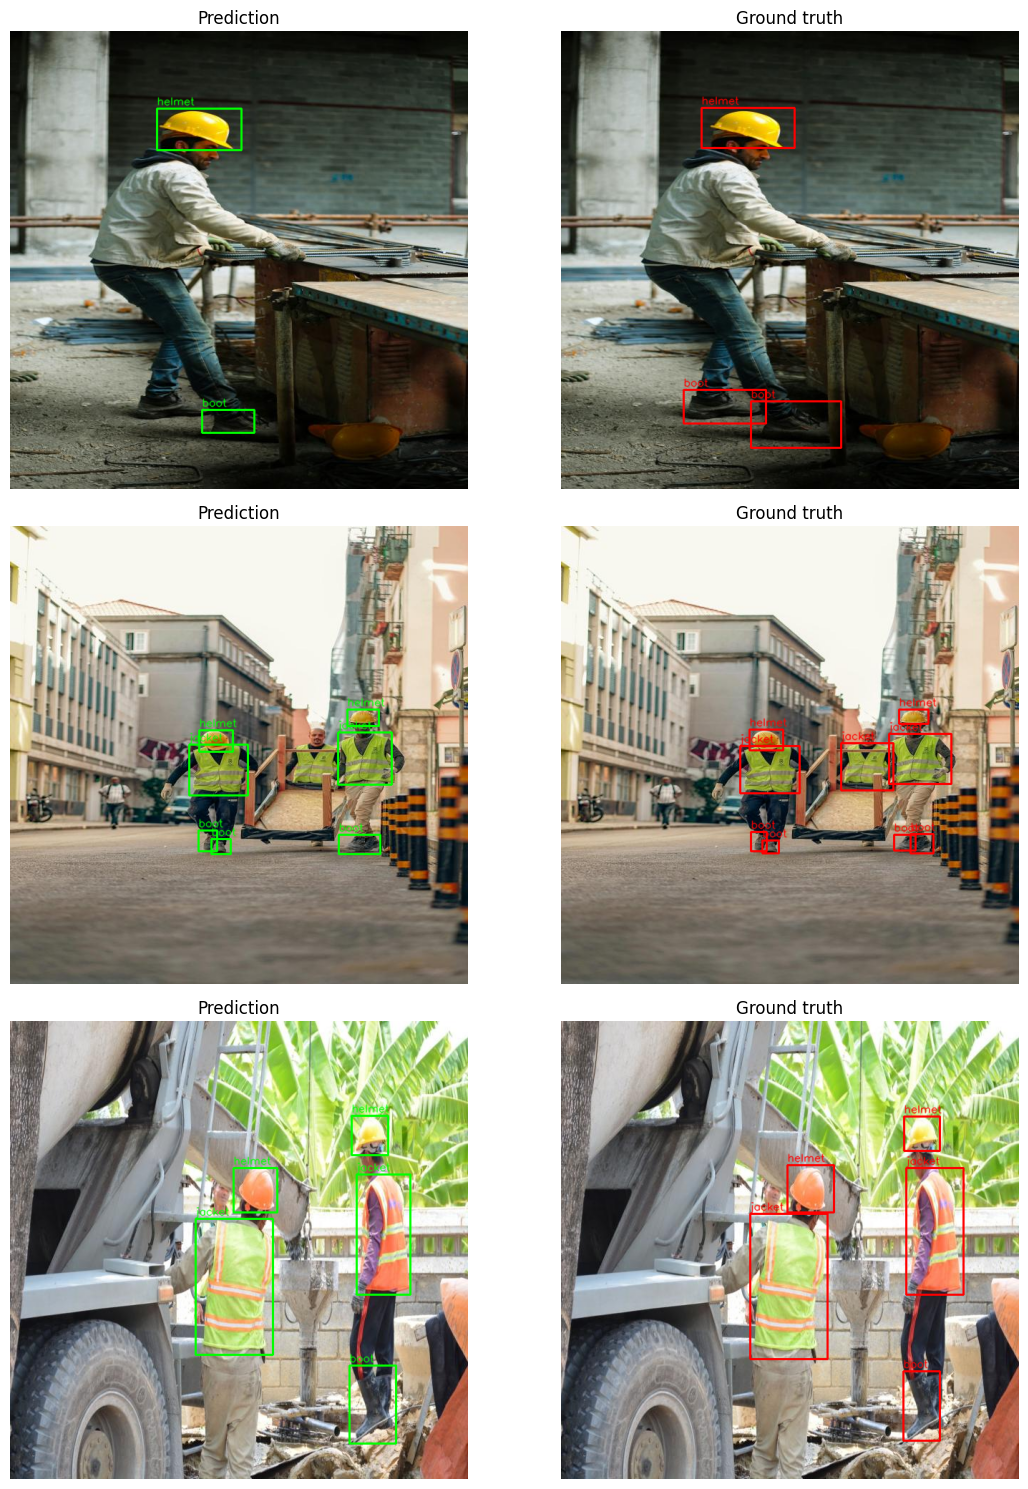

In [8]:
import matplotlib.pyplot as plt


n = min(3, len(paths))
fig, axes = plt.subplots(n, 2, figsize=(12, 5 * n))
axes = np.atleast_2d(axes)
for i in range(n):
    img = cv2.imread(paths[i])
    p = draw(img, preds_at_op[i], (0, 255, 0))
    g = draw(img, ppe_targets[i], (0, 0, 255))
    axes[i, 0].imshow(cv2.cvtColor(p, cv2.COLOR_BGR2RGB)); axes[i, 0].set_title("Prediction")
    axes[i, 1].imshow(cv2.cvtColor(g, cv2.COLOR_BGR2RGB)); axes[i, 1].set_title("Ground truth")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout(); plt.show()